# Phase 03. The JEPA auxiliary loss, honestly measured.

Phase 01 established a strong SFT baseline (loss 0.07 plateau, 96/100 real-table usage, 74% mean token overlap, aliasing conventions learned).

Phase 02 showed that SFT alone does *not* create prompt-target representation alignment. The aligned-shuffled cosine gap stayed at zero even for the well-trained checkpoint.

The question this notebook answers: **can a JEPA-style auxiliary loss produce a gap that SFT alone cannot?**

## The auxiliary loss

For each `(prompt, target)` pair:

1. Encode the prompt view separately: `z_prompt = pool(model(prompt_view).hidden_states[-1])`
2. Encode the target view separately: `z_target = pool(model(target_view).hidden_states[-1])` (detached)
3. Predict target from prompt via a small MLP: `z_pred = predictor(z_prompt)`
4. `jepa_loss = 1 - cos(z_pred, z_target)` (or shuffled `z_target` for the placebo control)
5. `total_loss = ce_loss + lambda_jepa * jepa_loss`

Three modes, controlled by one dashboard knob:

- `"none"` runs pure SFT (redoes Phase 01, provides in-notebook baseline)
- `"aligned"` runs SFT + JEPA on aligned pairs
- `"shuffled"` runs SFT + JEPA on shuffled pairs (placebo control)

You run this notebook three times, dashboard-only changes, and compare all three at the end. That's the honest experimental design.


## What this notebook does not do

No LoRA. No QLoRA. No `[PRED]` token machinery. Those are Phases 04, 05, 07.

The minimal JEPA is what gets tested here — the simplest possible auxiliary objective, with the sharpest possible experimental control (shuffled-pair placebo). If the minimal version works, more elaborate variants can be evaluated against it. If the minimal version doesn't work, we know that too.


In [2]:

import json
import math
import os
import random
import re
import sys
import time
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModelForCausalLM, AutoTokenizer

# Walk up to the repo root so paths resolve regardless of where Jupyter
# was launched. pyproject.toml lives one level above notebooks/.
HERE = Path.cwd()
REPO = HERE
while not (REPO / "pyproject.toml").exists() and REPO != REPO.parent:
    REPO = REPO.parent
NOTEBOOK_DIR = REPO / "notebooks"
os.chdir(NOTEBOOK_DIR)

DATA_PATH = NOTEBOOK_DIR / "data" / "nl_sql.jsonl"
LOCAL_MODEL_DIR = NOTEBOOK_DIR / "model" / "Qwen2.5-0.5B-Instruct"
OUTPUT_DIR = NOTEBOOK_DIR / "03-outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

# Phase 01 / 02 reference outputs for comparison
P01_OUTPUT_DIR = NOTEBOOK_DIR / "01-outputs"
P02_OUTPUT_DIR = NOTEBOOK_DIR / "02-outputs"

print("notebook dir:", NOTEBOOK_DIR)
print("data file   :", DATA_PATH, "exists:", DATA_PATH.exists())
print("base model  :", LOCAL_MODEL_DIR, "exists:", LOCAL_MODEL_DIR.exists())
print("outputs     :", OUTPUT_DIR)


notebook dir: c:\Users\adria\OneDrive\Desktop\mini-llm-jepa\notebooks
data file   : c:\Users\adria\OneDrive\Desktop\mini-llm-jepa\notebooks\data\nl_sql.jsonl exists: True
base model  : c:\Users\adria\OneDrive\Desktop\mini-llm-jepa\notebooks\model\Qwen2.5-0.5B-Instruct exists: True
outputs     : c:\Users\adria\OneDrive\Desktop\mini-llm-jepa\notebooks\03-outputs


## The base model

Same `Qwen/Qwen2.5-0.5B-Instruct` as Phase 01 and 02.


In [3]:

from huggingface_hub import snapshot_download

if not (LOCAL_MODEL_DIR / "config.json").exists():
    print(f"Downloading Qwen/Qwen2.5-0.5B-Instruct -> {LOCAL_MODEL_DIR}")
    LOCAL_MODEL_DIR.mkdir(parents=True, exist_ok=True)
    snapshot_download(repo_id="Qwen/Qwen2.5-0.5B-Instruct", local_dir=str(LOCAL_MODEL_DIR))
    print("Downloaded.")
else:
    print(f"Base model already present at {LOCAL_MODEL_DIR}")

MODEL_NAME = str(LOCAL_MODEL_DIR)


Base model already present at c:\Users\adria\OneDrive\Desktop\mini-llm-jepa\notebooks\model\Qwen2.5-0.5B-Instruct


## Hyperparameter dashboard

Phase 01's Run 6 config, plus Phase 03-specific knobs at the bottom.

Change `JEPA_MODE` between runs to sweep across `"none"`, `"aligned"`, `"shuffled"`. Everything else stays the same for an apples-to-apples comparison.

Batch size is 4 (up from Phase 01's 1) because the shuffled-pair control needs multiple examples per batch to permute across. Effective batch stays at 16 via `GRAD_ACCUM_STEPS = 4`. Gradient checkpointing is on to fit the extra forward passes in 8GB VRAM.


In [4]:
# ─── Mode ───
JEPA_MODE = "aligned"        # "none" | "aligned" | "shuffled"
LAMBDA_JEPA = 0.1

# ─── Data ───
MAX_TRAIN_EXAMPLES = 1000
MAX_EVAL_EXAMPLES = 100
EVAL_FRACTION = 0.10
SEQ_LEN = 1024

# ─── Model ───
DTYPE = "auto"
DEVICE = "auto"
FREEZE_FIRST_N_LAYERS = 0
GRADIENT_CHECKPOINTING = True

# ─── Training ───
NUM_EPOCHS = 12
BATCH_SIZE = 2
GRAD_ACCUM_STEPS = 8          # effective batch = 16 for SFT and VICReg statistics
LEARNING_RATE = 2.5e-6
WEIGHT_DECAY = 0.05
MAX_GRAD_NORM = 1.0
SEED = 1337

# ─── Scheduler ───
SCHEDULER = "cosine"
WARMUP_RATIO = 0.05
MIN_LR_RATIO = 0.2

# ─── JEPA extraction ───
JEPA_LAYER = -1
JEPA_POOLING = "last_token"
JEPA_NORMALIZE = True
JEPA_DETACH_TARGET = True

# ─── Predictor ───
PREDICTOR_DEPTH = 2
PREDICTOR_HIDDEN = 896
PREDICTOR_DROPOUT = 0.0

# ─── Anti-collapse (BYOL / I-JEPA / VICReg style) ───
USE_MOMENTUM_TARGET = True    # Slow-moving EMA target encoder
MOMENTUM_TAU = 0.996           # Higher = slower target update

# VICReg stats are now BUFFERED across the grad_accum window: effective sample
# size for var/cov = BATCH_SIZE * GRAD_ACCUM_STEPS (here: 16).
LAMBDA_VAR = 5.0               # Bumped from 1.0 now that stats are meaningful
LAMBDA_COV = 0.05
VAR_TARGET = 1.0

# ─── Generation / eval ───
MAX_NEW_TOKENS = 512

# ─── Logging ───
LOG_EVERY = 5

# ─── Representation audit ───
N_PAIRS_AUDIT = 200
AUDIT_SHUFFLE_SEED = 42


## The data

Same 14k pairs as Phases 01 and 02. Same disjoint-per-epoch sampling.


In [5]:

SYSTEM_PROMPT = (
    "Translate the user's request into a single PostgreSQL statement. "
    "Reply with SQL only, ending in ';'."
)

def load_pairs(path):
    pairs = []
    for line in Path(path).read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if not line:
            continue
        obj = json.loads(line)
        pairs.append({"prompt": obj["prompt"], "target": obj["target"]})
    return pairs

def _chat_messages(prompt, target=None):
    msgs = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": prompt},
    ]
    if target is not None:
        msgs.append({"role": "assistant", "content": target})
    return msgs

def build_prompt_text(tokenizer, prompt):
    return tokenizer.apply_chat_template(
        _chat_messages(prompt, target=None),
        tokenize=False, add_generation_prompt=True,
    )

def build_target_text(tokenizer, target):
    return tokenizer.apply_chat_template(
        [{"role": "assistant", "content": target}],
        tokenize=False, add_generation_prompt=False,
    )

pairs = load_pairs(DATA_PATH)
print(f"{len(pairs)} pairs loaded")


14000 pairs loaded


## Tokenization: three views per example

For JEPA training, each micro-batch needs three things:
1. **SFT input** (`input_ids`, `attention_mask`, `labels`) — the concatenated prompt+target sequence with prompt tokens masked
2. **Prompt view** (`prompt_ids`, `prompt_attention_mask`) — the chat template up to the assistant marker, for pooling `z_prompt`
3. **Target view** (`target_ids`, `target_attention_mask`) — the assistant response with its role marker, for pooling `z_target`

All three come from the same underlying pair. The dataset yields them per-example, the collator pads them separately to different lengths.


In [6]:

def tokenize_pair(tokenizer, pair, max_len):
    """SFT tokenization from Phase 01. Prompt tokens get label -100."""
    prefix_text = tokenizer.apply_chat_template(
        _chat_messages(pair["prompt"], target=None),
        tokenize=False, add_generation_prompt=True,
    )
    full_text = tokenizer.apply_chat_template(
        _chat_messages(pair["prompt"], pair["target"]),
        tokenize=False, add_generation_prompt=False,
    )
    prefix_ids = tokenizer(prefix_text, add_special_tokens=False)["input_ids"]
    full_ids = tokenizer(full_text, add_special_tokens=False)["input_ids"]
    if len(full_ids) > max_len:
        full_ids = full_ids[:max_len]
    prefix_len = min(len(prefix_ids), len(full_ids))

    input_ids = torch.tensor(full_ids, dtype=torch.long)
    attention_mask = torch.ones_like(input_ids)
    labels = input_ids.clone()
    labels[:prefix_len] = -100
    return {"input_ids": input_ids, "attention_mask": attention_mask, "labels": labels}


class JEPADataset(Dataset):
    """Each __getitem__ returns SFT tensors PLUS separate prompt-view and target-view tokens."""
    def __init__(self, pairs, tokenizer, max_len):
        self.pairs = list(pairs)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        pair = self.pairs[idx]
        sft = tokenize_pair(self.tokenizer, pair, self.max_len)

        # Prompt view: chat template up to assistant marker (as Phase 02)
        prompt_view = build_prompt_text(self.tokenizer, pair["prompt"])
        prompt_ids = self.tokenizer(
            prompt_view, add_special_tokens=False, truncation=True, max_length=self.max_len
        )["input_ids"]

        # Target view: chat template wrapping just the assistant response
        target_view = build_target_text(self.tokenizer, pair["target"])
        target_ids = self.tokenizer(
            target_view, add_special_tokens=False, truncation=True, max_length=self.max_len
        )["input_ids"]

        return {
            **sft,
            "prompt_ids": torch.tensor(prompt_ids, dtype=torch.long),
            "target_ids": torch.tensor(target_ids, dtype=torch.long),
        }


def collate_jepa(batch, pad_token_id):
    """Pad the three views separately. Returns 7 tensors."""
    max_sft = max(item["input_ids"].shape[0] for item in batch)
    max_p   = max(item["prompt_ids"].shape[0] for item in batch)
    max_t   = max(item["target_ids"].shape[0] for item in batch)

    def _pad(key, max_len, fill_id):
        out = torch.full((len(batch), max_len), fill_id, dtype=torch.long)
        for i, item in enumerate(batch):
            n = item[key].shape[0]
            out[i, :n] = item[key]
        return out

    def _mask(key, max_len):
        out = torch.zeros((len(batch), max_len), dtype=torch.long)
        for i, item in enumerate(batch):
            n = item[key].shape[0]
            out[i, :n] = 1
        return out

    input_ids = _pad("input_ids", max_sft, pad_token_id)
    attention_mask = _mask("input_ids", max_sft)
    labels = torch.full((len(batch), max_sft), -100, dtype=torch.long)
    for i, item in enumerate(batch):
        n = item["labels"].shape[0]
        labels[i, :n] = item["labels"]

    prompt_ids = _pad("prompt_ids", max_p, pad_token_id)
    prompt_attention_mask = _mask("prompt_ids", max_p)

    target_ids = _pad("target_ids", max_t, pad_token_id)
    target_attention_mask = _mask("target_ids", max_t)

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels,
        "prompt_ids": prompt_ids,
        "prompt_attention_mask": prompt_attention_mask,
        "target_ids": target_ids,
        "target_attention_mask": target_attention_mask,
    }


## Pooling functions

Standard from Phase 02.


In [7]:

def pool_last_token(hidden_states, attention_mask):
    lengths = attention_mask.sum(dim=1) - 1
    batch_idx = torch.arange(hidden_states.shape[0], device=hidden_states.device)
    return hidden_states[batch_idx, lengths]

def pool_mean(hidden_states, attention_mask):
    mask = attention_mask.unsqueeze(-1).float()
    summed = (hidden_states * mask).sum(dim=1)
    count = mask.sum(dim=1).clamp_min(1.0)
    return summed / count

def pool_first_token(hidden_states, attention_mask):
    return hidden_states[:, 0, :]

POOL_FNS = {"last_token": pool_last_token, "mean": pool_mean, "first_token": pool_first_token}


## The predictor

Tiny MLP. Its whole job is to map prompt representations into target representation space. Depth 2 means one hidden layer + GELU + output layer. About 1.6M params, negligible compared to the 494M-param base model.

The predictor is what makes JEPA a *learnable* alignment objective rather than just a similarity constraint. Without it, the loss would push prompt and target reps to be identical, which is a strong (probably too strong) constraint.


In [8]:

class Predictor(nn.Module):
    """MLP that maps z_prompt -> predicted z_target.

    Small compared to the LM. For hidden_dim=896 and depth=2, ~1.6M params.
    """
    def __init__(self, hidden_dim, depth=2, dropout=0.0):
        super().__init__()
        layers = []
        for _ in range(depth - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.GELU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
        layers.append(nn.Linear(hidden_dim, hidden_dim))
        self.mlp = nn.Sequential(*layers)

    def forward(self, x):
        return self.mlp(x)


## Load the model + predictor. Set gradient checkpointing.

Two forward passes per micro-batch have their gradients tracked (SFT + prompt-view). The target-view forward is under `torch.no_grad()` since target representation is detached anyway.


In [9]:

def pick_dtype(name, device):
    if name == "auto":
        if device == "cuda" and torch.cuda.is_bf16_supported():
            return torch.bfloat16
        return torch.float32
    return {
        "float32": torch.float32, "fp32": torch.float32,
        "float16": torch.float16, "fp16": torch.float16,
        "bfloat16": torch.bfloat16, "bf16": torch.bfloat16,
    }[name]

def pick_device(name):
    if name == "auto":
        return "cuda" if torch.cuda.is_available() else "cpu"
    return name

device = pick_device(DEVICE)
dtype = pick_dtype(DTYPE, device)
print(f"device: {device}, dtype: {dtype}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, dtype=dtype)
model.to(device)

if GRADIENT_CHECKPOINTING:
    model.gradient_checkpointing_enable()
    model.config.use_cache = False

hidden_dim = model.config.hidden_size
predictor = Predictor(hidden_dim=PREDICTOR_HIDDEN, depth=PREDICTOR_DEPTH, dropout=PREDICTOR_DROPOUT)
predictor.to(device).to(dtype)

# Freeze bottom N layers if requested
inner = model.model
n_layers_total = len(inner.layers)
if FREEZE_FIRST_N_LAYERS > 0:
    n = min(FREEZE_FIRST_N_LAYERS, n_layers_total)
    for p in inner.embed_tokens.parameters():
        p.requires_grad_(False)
    for layer in inner.layers[:n]:
        for p in layer.parameters():
            p.requires_grad_(False)
    print(f"Froze embedding + {n}/{n_layers_total} transformer blocks.")

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
pred_params = sum(p.numel() for p in predictor.parameters())
print(f"Trainable LM params: {trainable:,} / {total:,}  ({100*trainable/total:.1f}%)")
print(f"Predictor params    : {pred_params:,}")
print(f"JEPA_MODE           : {JEPA_MODE}")
print(f"LAMBDA_JEPA         : {LAMBDA_JEPA}")

# ─── Momentum target encoder (BYOL / I-JEPA style) ───
# A slow-moving EMA copy of the main model. Its parameters are updated by
# EMA after each optimizer step. Because the target is a moving target,
# the online model cannot cheaply collapse onto a fixed centroid.
momentum_encoder = None
if JEPA_MODE != "none" and USE_MOMENTUM_TARGET:
    print("Loading momentum target encoder (adds ~1GB VRAM)...")
    momentum_encoder = AutoModelForCausalLM.from_pretrained(MODEL_NAME, dtype=dtype)
    momentum_encoder.to(device)
    momentum_encoder.eval()
    for p in momentum_encoder.parameters():
        p.requires_grad_(False)
    # Turn off gradient checkpointing on the momentum encoder (only used in no_grad)
    if hasattr(momentum_encoder, "gradient_checkpointing_disable"):
        try:
            momentum_encoder.gradient_checkpointing_disable()
        except Exception:
            pass
    momentum_encoder.config.use_cache = False
    print(f"  momentum_tau = {MOMENTUM_TAU}")
elif JEPA_MODE != "none":
    print("Momentum encoder DISABLED (USE_MOMENTUM_TARGET=False). "
          "Target reps come from the main model with no_grad instead.")


device: cuda, dtype: torch.bfloat16


Loading weights: 100%|██████████| 290/290 [00:00<00:00, 2006.52it/s]


Trainable LM params: 494,032,768 / 494,032,768  (100.0%)
Predictor params    : 1,607,424
JEPA_MODE           : aligned
LAMBDA_JEPA         : 0.1
Loading momentum target encoder (adds ~1GB VRAM)...


Loading weights: 100%|██████████| 290/290 [00:00<00:00, 3698.16it/s]


  momentum_tau = 0.996


## Optimizer and scheduler

AdamW over the union of the LM's trainable params and all predictor params. Same cosine schedule as Phase 01 Run 6.


In [10]:

def set_seed(seed):
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def split_pairs(pairs, eval_fraction, seed):
    rng = random.Random(seed)
    idx = list(range(len(pairs))); rng.shuffle(idx)
    n_eval = max(1, int(len(pairs) * eval_fraction))
    eval_idx = set(idx[:n_eval])
    train = [pairs[i] for i in range(len(pairs)) if i not in eval_idx]
    evl = [pairs[i] for i in range(len(pairs)) if i in eval_idx]
    return train, evl

def build_scheduler(optim, kind, total_steps, warmup_ratio, min_lr_ratio):
    if kind == "none":
        return None
    warmup = int(total_steps * warmup_ratio)
    if kind == "linear":
        def lr_lambda(step):
            if step < warmup:
                return step / max(1, warmup)
            return max(0.0, (total_steps - step) / max(1, total_steps - warmup))
        return LambdaLR(optim, lr_lambda)
    if kind == "cosine":
        def lr_lambda(step):
            if step < warmup:
                return step / max(1, warmup)
            progress = (step - warmup) / max(1, total_steps - warmup)
            cos = 0.5 * (1.0 + math.cos(math.pi * progress))
            return min_lr_ratio + (1.0 - min_lr_ratio) * cos
        return LambdaLR(optim, lr_lambda)
    raise ValueError(f"unknown scheduler {kind!r}")

set_seed(SEED)
train_pool, eval_pairs = split_pairs(pairs, EVAL_FRACTION, SEED)
eval_pairs = eval_pairs[:MAX_EVAL_EXAMPLES]
examples_per_epoch = min(MAX_TRAIN_EXAMPLES, len(train_pool))

rng = random.Random(SEED)
shuffled_pool = train_pool.copy()
rng.shuffle(shuffled_pool)

max_possible_epochs = len(shuffled_pool) // examples_per_epoch
if NUM_EPOCHS > max_possible_epochs:
    print(f"NOTE: NUM_EPOCHS={NUM_EPOCHS} would deplete pool; capping at {max_possible_epochs}.")
    effective_epochs = max_possible_epochs
else:
    effective_epochs = NUM_EPOCHS

epoch_slices = [
    shuffled_pool[i * examples_per_epoch : (i + 1) * examples_per_epoch]
    for i in range(effective_epochs)
]
total_used = sum(len(s) for s in epoch_slices)
print(f"train pool: {len(train_pool)} pairs")
print(f"epochs planned: {effective_epochs} x {examples_per_epoch} = {total_used} unique examples")
print(f"eval pairs: {len(eval_pairs)}")

micro_per_epoch = math.ceil(examples_per_epoch / BATCH_SIZE)
total_optim_steps = max(1, (micro_per_epoch * effective_epochs) // GRAD_ACCUM_STEPS)
print(f"micro-batches per epoch: {micro_per_epoch}, total optim steps: {total_optim_steps}")

# Joint parameter list
all_params = [p for p in model.parameters() if p.requires_grad] + list(predictor.parameters())
optim = AdamW(all_params, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = build_scheduler(optim, SCHEDULER, total_optim_steps, WARMUP_RATIO, MIN_LR_RATIO)
print(f"scheduler: {SCHEDULER}, warmup: {WARMUP_RATIO}, min_lr_ratio: {MIN_LR_RATIO}")


train pool: 12600 pairs
epochs planned: 12 x 1000 = 12000 unique examples
eval pairs: 100
micro-batches per epoch: 500, total optim steps: 750
scheduler: cosine, warmup: 0.05, min_lr_ratio: 0.2


## Eval the untrained base model first

The "before" snapshot. Same evaluation loop as Phase 01. On 100 examples this takes ~10-15 min on CUDA.


In [11]:

def normalize_sql(s):
    s = re.sub(r"\s+", " ", s.strip().lower())
    return re.sub(r"\s*;\s*", ";", s)

def exact_match(pred, target):
    return pred.strip() == target.strip()

def normalized_exact_match(pred, target):
    return normalize_sql(pred) == normalize_sql(target)

def _truncate_to_first_statement(text):
    return text[: text.index(";") + 1] if ";" in text else text

@torch.no_grad()
def evaluate_pairs(model, tokenizer, eval_pairs, max_new_tokens):
    model.eval()
    dev = next(model.parameters()).device
    em = nem = 0
    samples = []
    for p in eval_pairs:
        prefix = build_prompt_text(tokenizer, p["prompt"])
        ids = tokenizer(prefix, return_tensors="pt")["input_ids"].to(dev)
        gen = model.generate(
            input_ids=ids,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
        text = tokenizer.decode(gen[0, ids.shape[1]:], skip_special_tokens=True)
        pred = _truncate_to_first_statement(text).strip()
        e = exact_match(pred, p["target"])
        ne = normalized_exact_match(pred, p["target"])
        em += int(e); nem += int(ne)
        samples.append({
            "prompt": p["prompt"], "target": p["target"], "pred": pred,
            "exact_match": e, "normalized_exact_match": ne,
        })
    n = max(len(eval_pairs), 1)
    return {"n": n, "exact_match": em / n, "normalized_exact_match": nem / n, "samples": samples}

t0 = time.time()
untrained = evaluate_pairs(model, tokenizer, eval_pairs, MAX_NEW_TOKENS)
print(f"Untrained eval took {time.time() - t0:.1f}s")
print(f"  exact match     : {untrained['exact_match']:.1%}")
print(f"  normalized EM   : {untrained['normalized_exact_match']:.1%}")


Untrained eval took 392.1s
  exact match     : 0.0%
  normalized EM   : 0.0%


## The JEPA-aware training loop

Per micro-batch:

1. **SFT forward** (input_ids, attention_mask, labels) → `ce_loss` (has grad)
2. If `JEPA_MODE != "none"`:
   - **Prompt-view forward** (prompt_ids, prompt_attention_mask, output_hidden_states=True) → `z_prompt` (has grad)
   - **Target-view forward** under `no_grad` (target_ids, target_attention_mask) → `z_target` (detached)
   - If `JEPA_MODE == "shuffled"`: permute `z_target` within the batch
   - Predictor: `z_pred = predictor(z_prompt)`
   - Normalize both if `JEPA_NORMALIZE`
   - `jepa_loss = 1 - cos(z_pred, z_target).mean()`
3. `total_loss = ce_loss + LAMBDA_JEPA * jepa_loss`
4. Backward, accumulate grads across `GRAD_ACCUM_STEPS`, then optimizer step

The training log tracks CE loss, JEPA loss, total loss, and LR separately per optim step. Interrupt safely — `KeyboardInterrupt` returns partial history.


In [12]:
def variance_loss(z, target_std=1.0, eps=1e-6):
    """VICReg variance term. Encourages per-dim std of z to be >= target_std."""
    std_z = torch.sqrt(z.var(dim=0) + eps)
    return torch.nn.functional.relu(target_std - std_z).mean()


def covariance_loss(z):
    """VICReg covariance term. Penalizes off-diagonal cross-correlation."""
    B, D = z.shape
    if B <= 1:
        return z.new_zeros(())
    z_c = z - z.mean(dim=0, keepdim=True)
    cov = (z_c.T @ z_c) / (B - 1)
    off = cov - torch.diag(torch.diag(cov))
    return (off ** 2).sum() / D


@torch.no_grad()
def update_momentum(target_model, source_model, tau):
    """EMA update: target = tau * target + (1 - tau) * source."""
    for tp, sp in zip(target_model.parameters(), source_model.parameters()):
        tp.data.mul_(tau).add_(sp.data, alpha=1.0 - tau)


def train_jepa(
    model, predictor, tokenizer, epoch_slices, batch_size, seq_len,
    optim, scheduler, grad_accum_steps, max_grad_norm, log_every, log_path,
    jepa_mode, lambda_jepa, jepa_layer_idx, jepa_pooling, jepa_normalize, jepa_detach_target,
    momentum_encoder=None, momentum_tau=0.996,
    lambda_var=0.0, lambda_cov=0.0, var_target=1.0,
):
    model.train()
    predictor.train()
    dev = next(model.parameters()).device
    pool_fn = POOL_FNS[jepa_pooling]
    global_step = 0
    accum = 0
    running_ce = 0.0
    running_jepa = 0.0
    running_var = 0.0
    running_cov = 0.0
    running_eff_bsz = 0.0
    history = []

    # Buffered VICReg: detached z_pred from earlier micro-batches within the current
    # grad_accum window. Resets after each optimizer step.
    vicreg_buffer_pred = []

    try:
        with open(log_path, "w", encoding="utf-8") as log_f:
            for epoch, epoch_pairs in enumerate(epoch_slices):
                ds = JEPADataset(epoch_pairs, tokenizer, seq_len)
                loader = DataLoader(
                    ds, batch_size=batch_size, shuffle=True,
                    collate_fn=lambda b: collate_jepa(b, tokenizer.pad_token_id),
                )
                target_source = "momentum" if momentum_encoder is not None else ("no_grad(main)" if jepa_detach_target else "main")
                print(f"[epoch {epoch}] {len(epoch_pairs)} disjoint pairs, batch_size={batch_size}, target source: {target_source}")

                for batch in loader:
                    batch = {k: v.to(dev) for k, v in batch.items()}

                    # 1. SFT forward
                    sft_out = model(
                        input_ids=batch["input_ids"],
                        attention_mask=batch["attention_mask"],
                        labels=batch["labels"],
                    )
                    ce_loss = sft_out.loss

                    var_loss = torch.tensor(0.0, device=dev)
                    cov_loss = torch.tensor(0.0, device=dev)
                    jepa_loss = torch.tensor(0.0, device=dev)
                    effective_bsz = float(batch_size)

                    if jepa_mode != "none":
                        # 2. Prompt-view forward (with grad)
                        prompt_out = model(
                            input_ids=batch["prompt_ids"],
                            attention_mask=batch["prompt_attention_mask"],
                            output_hidden_states=True,
                        )
                        z_prompt = pool_fn(
                            prompt_out.hidden_states[jepa_layer_idx],
                            batch["prompt_attention_mask"],
                        )

                        # 3. Target-view via momentum encoder or no-grad main
                        with torch.no_grad():
                            target_model = momentum_encoder if momentum_encoder is not None else model
                            target_out = target_model(
                                input_ids=batch["target_ids"],
                                attention_mask=batch["target_attention_mask"],
                                output_hidden_states=True,
                            )
                            z_target = pool_fn(
                                target_out.hidden_states[jepa_layer_idx],
                                batch["target_attention_mask"],
                            )
                        z_target = z_target.detach()

                        # 4. Shuffled control
                        if jepa_mode == "shuffled":
                            perm = torch.randperm(z_target.shape[0], device=dev)
                            z_target = z_target[perm]

                        # 5. Predictor
                        z_pred = predictor(z_prompt)

                        # 6. VICReg with buffered stats:
                        #    concat current z_pred (WITH grad) + buffered detached z_pred
                        #    from earlier micro-batches in this accumulation window.
                        if lambda_var > 0 or lambda_cov > 0:
                            z_pred_f = z_pred.float()
                            if vicreg_buffer_pred:
                                past = torch.cat(vicreg_buffer_pred, dim=0)  # detached
                                z_for_stats = torch.cat([z_pred_f, past], dim=0)
                            else:
                                z_for_stats = z_pred_f
                            effective_bsz = float(z_for_stats.shape[0])
                            if lambda_var > 0:
                                var_loss = variance_loss(z_for_stats, target_std=var_target)
                            if lambda_cov > 0:
                                cov_loss = covariance_loss(z_for_stats)

                        # 7. Cosine JEPA loss
                        if jepa_normalize:
                            z_pred_n = torch.nn.functional.normalize(z_pred, dim=-1)
                            z_target_n = torch.nn.functional.normalize(z_target, dim=-1)
                        else:
                            z_pred_n, z_target_n = z_pred, z_target
                        cos_sim = (z_pred_n * z_target_n).sum(dim=-1)
                        jepa_loss = 1.0 - cos_sim.mean()

                        total_loss = ce_loss + lambda_jepa * jepa_loss + lambda_var * var_loss + lambda_cov * cov_loss

                        # 8. Update buffer with detached copy of current z_pred
                        #    (append AFTER using it — we don't include current in past)
                        vicreg_buffer_pred.append(z_pred.detach().float())

                        running_jepa += jepa_loss.item()
                        running_var += var_loss.item()
                        running_cov += cov_loss.item()
                        running_eff_bsz += effective_bsz
                    else:
                        total_loss = ce_loss

                    (total_loss / grad_accum_steps).backward()
                    running_ce += ce_loss.item()
                    accum += 1

                    if accum == grad_accum_steps:
                        torch.nn.utils.clip_grad_norm_(
                            [p for p in model.parameters() if p.requires_grad] +
                            list(predictor.parameters()),
                            max_grad_norm,
                        )
                        optim.step()
                        if scheduler is not None:
                            scheduler.step()
                        optim.zero_grad()

                        if momentum_encoder is not None:
                            update_momentum(momentum_encoder, model, momentum_tau)

                        # Reset VICReg buffer at the end of the grad_accum window
                        vicreg_buffer_pred = []

                        accum = 0
                        global_step += 1

                        if global_step % log_every == 0:
                            denom = grad_accum_steps * log_every
                            avg_ce = running_ce / denom
                            avg_jepa = running_jepa / denom if jepa_mode != "none" else 0.0
                            avg_var = running_var / denom if jepa_mode != "none" else 0.0
                            avg_cov = running_cov / denom if jepa_mode != "none" else 0.0
                            avg_eff_bsz = running_eff_bsz / denom if jepa_mode != "none" else 0.0
                            lr = optim.param_groups[0]["lr"]
                            total = avg_ce + lambda_jepa * avg_jepa + lambda_var * avg_var + lambda_cov * avg_cov
                            rec = {
                                "step": global_step, "epoch": epoch,
                                "ce_loss": avg_ce, "jepa_loss": avg_jepa,
                                "var_loss": avg_var, "cov_loss": avg_cov,
                                "eff_bsz": avg_eff_bsz,
                                "total_loss": total, "lr": lr,
                            }
                            log_f.write(json.dumps(rec) + "\n")
                            log_f.flush()
                            history.append(rec)
                            if jepa_mode != "none":
                                print(f"  step {global_step:>3}  epoch {epoch}  ce {avg_ce:.4f}  jepa {avg_jepa:.4f}  var {avg_var:.4f}  cov {avg_cov:.4f}  eff_bsz {avg_eff_bsz:.1f}  lr {lr:.2e}")
                            else:
                                print(f"  step {global_step:>3}  epoch {epoch}  ce {avg_ce:.4f}  lr {lr:.2e}")
                            running_ce = 0.0
                            running_jepa = 0.0
                            running_var = 0.0
                            running_cov = 0.0
                            running_eff_bsz = 0.0
    except KeyboardInterrupt:
        print(f"\nInterrupted at step {global_step}. Returning partial history.")
        return history
    return history


t0 = time.time()
history = train_jepa(
    model, predictor, tokenizer, epoch_slices, BATCH_SIZE, SEQ_LEN,
    optim, scheduler, GRAD_ACCUM_STEPS, MAX_GRAD_NORM, LOG_EVERY,
    OUTPUT_DIR / f"train_log_{JEPA_MODE}.jsonl",
    JEPA_MODE, LAMBDA_JEPA, JEPA_LAYER, JEPA_POOLING, JEPA_NORMALIZE, JEPA_DETACH_TARGET,
    momentum_encoder=momentum_encoder,
    momentum_tau=MOMENTUM_TAU,
    lambda_var=LAMBDA_VAR,
    lambda_cov=LAMBDA_COV,
    var_target=VAR_TARGET,
)
print(f"\nTraining took {time.time() - t0:.1f}s. {len(history)} log records.")


[epoch 0] 1000 disjoint pairs, batch_size=2, target source: momentum
  step   5  epoch 0  ce 1.2103  jepa 1.0127  var 0.6787  cov 10.6820  eff_bsz 9.0  lr 3.38e-07
  step  10  epoch 0  ce 1.2246  jepa 1.0104  var 0.6314  cov 12.9255  eff_bsz 9.0  lr 6.76e-07
  step  15  epoch 0  ce 1.2254  jepa 1.0109  var 0.7151  cov 8.2055  eff_bsz 9.0  lr 1.01e-06
  step  20  epoch 0  ce 1.2079  jepa 1.0111  var 0.6555  cov 11.7242  eff_bsz 9.0  lr 1.35e-06
  step  25  epoch 0  ce 1.1938  jepa 1.0111  var 0.6836  cov 6.4413  eff_bsz 9.0  lr 1.69e-06
  step  30  epoch 0  ce 1.1699  jepa 1.0123  var 0.6707  cov 10.4704  eff_bsz 9.0  lr 2.03e-06
  step  35  epoch 0  ce 1.1497  jepa 1.0107  var 0.7325  cov 4.7997  eff_bsz 9.0  lr 2.36e-06
  step  40  epoch 0  ce 1.1097  jepa 1.0098  var 0.7523  cov 2.7566  eff_bsz 9.0  lr 2.50e-06
  step  45  epoch 0  ce 1.0544  jepa 1.0080  var 0.7478  cov 2.9508  eff_bsz 9.0  lr 2.50e-06
  step  50  epoch 0  ce 1.0198  jepa 1.0051  var 0.7400  cov 3.1772  eff_bsz 9.0 

## Loss curves — CE, JEPA, and LR

For `JEPA_MODE != "none"`: three panels (CE, JEPA, LR). For `"none"`: two panels (CE, LR) — JEPA loss is all zero.

The JEPA panel is the important one for aligned mode. If JEPA loss drops as training proceeds, the predictor is learning to map z_prompt to z_target. If it stays flat, the auxiliary objective isn't finding signal.

For the shuffled mode, JEPA loss *should* stay high — you're asking the predictor to hit a random target, which it fundamentally cannot do. If shuffled JEPA loss drops significantly, something is off (the model may be collapsing all target reps to a single point, making the shuffled target reachable).


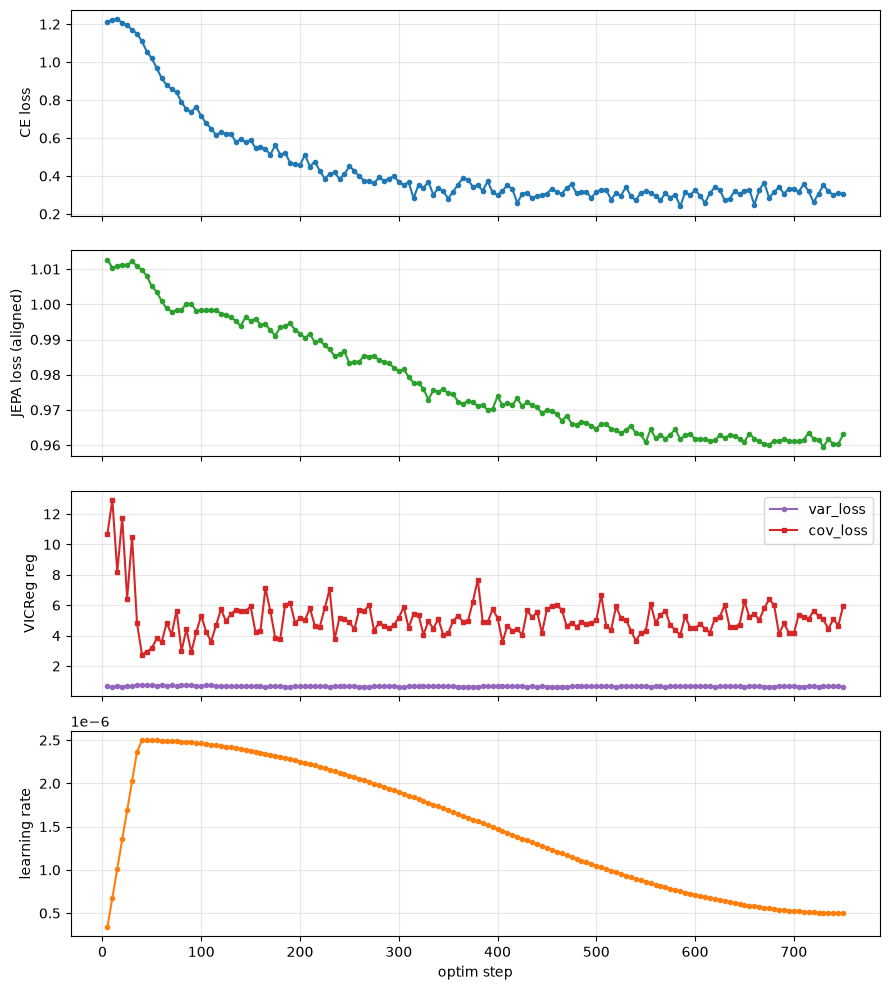

In [13]:
try:
    import matplotlib.pyplot as plt
    if history:
        steps = [r["step"] for r in history]
        ce = [r["ce_loss"] for r in history]
        jepa = [r["jepa_loss"] for r in history]
        varl = [r.get("var_loss", 0.0) for r in history]
        covl = [r.get("cov_loss", 0.0) for r in history]
        lrs = [r["lr"] for r in history]

        if JEPA_MODE != "none":
            fig, axes = plt.subplots(4, 1, figsize=(9, 10), sharex=True)
            axes[0].plot(steps, ce, marker="o", markersize=3, color="tab:blue")
            axes[0].set_ylabel("CE loss")
            axes[0].grid(True, alpha=0.3)

            axes[1].plot(steps, jepa, marker="o", markersize=3, color="tab:green")
            axes[1].set_ylabel(f"JEPA loss ({JEPA_MODE})")
            axes[1].grid(True, alpha=0.3)

            axes[2].plot(steps, varl, marker="o", markersize=3, color="tab:purple", label="var_loss")
            axes[2].plot(steps, covl, marker="s", markersize=3, color="tab:red", label="cov_loss")
            axes[2].set_ylabel("VICReg reg")
            axes[2].legend(loc="upper right")
            axes[2].grid(True, alpha=0.3)

            axes[3].plot(steps, lrs, marker="o", markersize=3, color="tab:orange")
            axes[3].set_ylabel("learning rate")
            axes[3].set_xlabel("optim step")
            axes[3].grid(True, alpha=0.3)
        else:
            fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
            axes[0].plot(steps, ce, marker="o", markersize=3, color="tab:blue")
            axes[0].set_ylabel("CE loss")
            axes[0].grid(True, alpha=0.3)
            axes[1].plot(steps, lrs, marker="o", markersize=3, color="tab:orange")
            axes[1].set_ylabel("learning rate")
            axes[1].set_xlabel("optim step")
            axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()
    else:
        print("No log records; did training finish an optim step?")
except ImportError:
    print("matplotlib not installed.")


## Eval the trained model

Same held-out set, same greedy decoding. Same metrics.


In [ ]:

t0 = time.time()
trained = evaluate_pairs(model, tokenizer, eval_pairs, MAX_NEW_TOKENS)
print(f"Trained eval took {time.time() - t0:.1f}s")
print(f"  exact match     : {trained['exact_match']:.1%}")
print(f"  normalized EM   : {trained['normalized_exact_match']:.1%}")

# Save trained checkpoint + predictor separately (per JEPA_MODE)
save_dir = OUTPUT_DIR / f"model_{JEPA_MODE}"
save_dir.mkdir(exist_ok=True)
model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)
torch.save(predictor.state_dict(), save_dir / "predictor.pt")

(OUTPUT_DIR / f"eval_base_{JEPA_MODE}.json").write_text(
    json.dumps({k: v for k, v in untrained.items() if k != "samples"}, indent=2),
    encoding="utf-8",
)
(OUTPUT_DIR / f"eval_{JEPA_MODE}.json").write_text(
    json.dumps({k: v for k, v in trained.items() if k != "samples"}, indent=2),
    encoding="utf-8",
)
(OUTPUT_DIR / f"eval_samples_base_{JEPA_MODE}.jsonl").write_text(
    "\n".join(json.dumps(s) for s in untrained["samples"]) + "\n", encoding="utf-8",
)
(OUTPUT_DIR / f"eval_samples_{JEPA_MODE}.jsonl").write_text(
    "\n".join(json.dumps(s) for s in trained["samples"]) + "\n", encoding="utf-8",
)
print(f"Saved to {save_dir}")


## Representation audit (Phase 02 inline)

Compute the same aligned-vs-shuffled cosine gap Phase 02 measured, but on this run's trained model. If JEPA did what it claims, the aligned mode should show a wider gap than the shuffled mode (or the "none" baseline).


In [ ]:

@torch.no_grad()
def encode_view(model, tokenizer, texts, layer_idx, pooling, batch_size=4):
    pool_fn = POOL_FNS[pooling]
    out_chunks = []
    for i in range(0, len(texts), batch_size):
        chunk = texts[i:i + batch_size]
        enc = tokenizer(chunk, return_tensors="pt", padding=True, truncation=True, max_length=SEQ_LEN).to(model.device)
        out = model(**enc, output_hidden_states=True)
        hs = out.hidden_states[layer_idx]
        z = pool_fn(hs, enc["attention_mask"])
        out_chunks.append(z.float().cpu())
    return torch.cat(out_chunks, dim=0)

def repr_stats(z):
    norms = z.norm(dim=-1)
    return {
        "shape": list(z.shape),
        "mean_norm": float(norms.mean()),
        "std_of_norms": float(norms.std()),
        "mean_per_dim_std": float(z.std(dim=0).mean()),
    }

def pairwise_cos(a, b, normalize):
    if normalize:
        a = a / a.norm(dim=-1, keepdim=True).clamp_min(1e-8)
        b = b / b.norm(dim=-1, keepdim=True).clamp_min(1e-8)
    return (a * b).sum(dim=-1)

# Sample from the same held-out data
audit_pairs = pairs[:N_PAIRS_AUDIT]
prompt_texts = [build_prompt_text(tokenizer, p["prompt"]) for p in audit_pairs]
target_texts = [build_target_text(tokenizer, p["target"]) for p in audit_pairs]

model.eval()
print("Encoding prompt view...")
z_prompt = encode_view(model, tokenizer, prompt_texts, JEPA_LAYER, JEPA_POOLING)
print("Encoding target view...")
z_target = encode_view(model, tokenizer, target_texts, JEPA_LAYER, JEPA_POOLING)

# Aligned vs shuffled cosine
aligned = pairwise_cos(z_prompt, z_target, JEPA_NORMALIZE)
rng = torch.Generator().manual_seed(AUDIT_SHUFFLE_SEED)
perm = torch.randperm(z_target.shape[0], generator=rng)
shuffled = pairwise_cos(z_prompt, z_target[perm], JEPA_NORMALIZE)

audit_result = {
    "jepa_mode": JEPA_MODE,
    "lambda_jepa": LAMBDA_JEPA,
    "prompt_stats": repr_stats(z_prompt),
    "target_stats": repr_stats(z_target),
    "aligned_mean": float(aligned.mean()),
    "aligned_std": float(aligned.std()),
    "shuffled_mean": float(shuffled.mean()),
    "shuffled_std": float(shuffled.std()),
    "gap": float(aligned.mean() - shuffled.mean()),
}
(OUTPUT_DIR / f"repr_audit_{JEPA_MODE}.json").write_text(
    json.dumps(audit_result, indent=2), encoding="utf-8"
)

from IPython.display import Markdown, display
tbl = "| set | shape | mean_norm | std_of_norms | mean_per_dim_std |\n| --- | --- | --- | --- | --- |\n"
for name, s in [("prompt", audit_result["prompt_stats"]), ("target", audit_result["target_stats"])]:
    tbl += f"| {name} | {tuple(s['shape'])} | {s['mean_norm']:.4f} | {s['std_of_norms']:.4f} | {s['mean_per_dim_std']:.4f} |\n"
display(Markdown(tbl))

print(f"\nAligned cosine   mean={audit_result['aligned_mean']:.4f}  std={audit_result['aligned_std']:.4f}")
print(f"Shuffled cosine  mean={audit_result['shuffled_mean']:.4f}  std={audit_result['shuffled_std']:.4f}")
print(f"GAP              {audit_result['gap']:+.4f}")


Encoding prompt view...
Encoding target view...


| set | shape | mean_norm | std_of_norms | mean_per_dim_std |
| --- | --- | --- | --- | --- |
| prompt | (200, 896) | 219.0064 | 0.3375 | 0.3579 |
| target | (200, 896) | 219.5988 | 0.1619 | 0.2646 |



Aligned cosine   mean=0.1888  std=0.0031
Shuffled cosine  mean=0.1887  std=0.0029
GAP              +0.0000


## Distribution plot


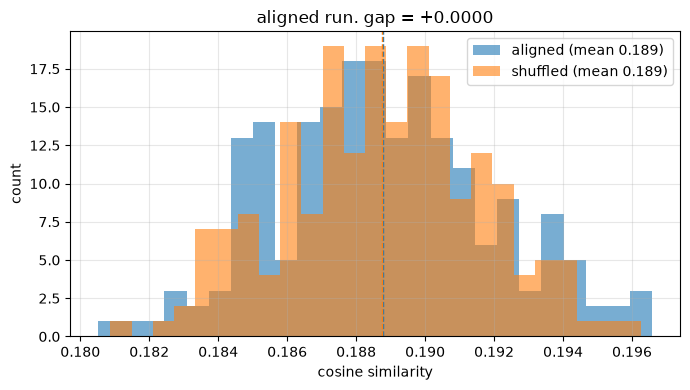

In [ ]:

try:
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(aligned.numpy(), bins=25, alpha=0.6, label=f"aligned (mean {audit_result['aligned_mean']:.3f})")
    ax.hist(shuffled.numpy(), bins=25, alpha=0.6, label=f"shuffled (mean {audit_result['shuffled_mean']:.3f})")
    ax.axvline(audit_result['aligned_mean'], color="tab:blue", linestyle="--", linewidth=1)
    ax.axvline(audit_result['shuffled_mean'], color="tab:orange", linestyle="--", linewidth=1)
    ax.set_title(f"{JEPA_MODE} run. gap = {audit_result['gap']:+.4f}")
    ax.set_xlabel("cosine similarity")
    ax.set_ylabel("count")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
except ImportError:
    print("matplotlib not installed.")


## Comparison across all runs

If you've run this notebook with `JEPA_MODE = "none"`, `"aligned"`, and `"shuffled"` in sequence, all three sets of artifacts are on disk in `03-outputs/`. The cell below reads them and prints a side-by-side.

Also compares to Phase 01 Run 6 (`01-outputs/eval.json`) and Phase 02 baseline (`02-outputs/repr_stats.json`) if present.


In [ ]:

from IPython.display import Markdown, display

def _try_load(p):
    try:
        return json.loads(Path(p).read_text())
    except Exception:
        return None

phase01 = _try_load(P01_OUTPUT_DIR / "eval.json")
phase02 = _try_load(P02_OUTPUT_DIR / "repr_stats.json")

rows = []
if phase01 is not None:
    rows.append(("Phase 01 (SFT, batch=1)", phase01.get("exact_match"), phase01.get("normalized_exact_match"), None))
for mode in ["none", "aligned", "shuffled"]:
    evalp = _try_load(OUTPUT_DIR / f"eval_{mode}.json")
    auditp = _try_load(OUTPUT_DIR / f"repr_audit_{mode}.json")
    if evalp is None and auditp is None:
        continue
    em = evalp.get("exact_match") if evalp else None
    nem = evalp.get("normalized_exact_match") if evalp else None
    gap = auditp.get("gap") if auditp else None
    rows.append((f"Phase 03 (JEPA={mode})", em, nem, gap))

hdr = "| run | strict EM | normalized EM | aligned-shuffled gap |\n| --- | --- | --- | --- |\n"
body = ""
for name, em, nem, gap in rows:
    em_s = f"{em:.1%}" if em is not None else "–"
    nem_s = f"{nem:.1%}" if nem is not None else "–"
    gap_s = f"{gap:+.4f}" if gap is not None else "–"
    body += f"| {name} | {em_s} | {nem_s} | {gap_s} |\n"
display(Markdown(hdr + body))

if phase02 is not None and phase02.get("cosines"):
    print("\nPhase 02 reference (SFT-only trained model):")
    for r in phase02["cosines"]:
        if r["name"] == "trained":
            print(f"  Phase 02 trained aligned={r['aligned_mean']:.4f}  shuffled={r['shuffled_mean']:.4f}  gap={r['gap']:+.4f}")


| run | strict EM | normalized EM | aligned-shuffled gap |
| --- | --- | --- | --- |
| Phase 01 (SFT, batch=1) | 0.0% | 0.0% | – |
| Phase 03 (JEPA=aligned) | 0.0% | 0.0% | +0.0000 |



Phase 02 reference (SFT-only trained model):
  Phase 02 trained aligned=0.1398  shuffled=0.1398  gap=-0.0000


## Reading the result honestly

The key comparison is **aligned gap vs shuffled gap vs "none" gap**.

- If **aligned > shuffled ≈ none**: JEPA's aligned objective produces a specific effect that the shuffled control cannot. That's real evidence for the JEPA mechanism.
- If **aligned ≈ shuffled > none**: both JEPA modes affect the gap uniformly. Something about the JEPA loss (not the alignment specifically) is doing the work — could be regularization, could be geometric shaping. Not a clean win for the alignment hypothesis.
- If **aligned ≈ shuffled ≈ none**: JEPA's effect on the gap is null at this lambda/scale/config. Try higher `LAMBDA_JEPA`, different pooling, different layer. If still null after honest exploration, that's a real research finding: the minimal JEPA formulation does not add value at 0.5B on this task.

Whatever the result, it's honest. The shuffled-pair control is what makes this credible.

For strict EM: this task's metric-rigidity means all three modes will likely stay at 0-a-few percent EM. The *interesting* signal is in the gap column and (from the diagnostic cell you can paste from Phase 01) the real-table usage / token overlap deltas.


## Predicted-cosine audit (the right JEPA metric)

The audit above measures `cos(z_prompt, z_target)` on raw pooled reps. But JEPA's loss trains `cos(predictor(z_prompt), z_target)`. Different vectors.

This cell measures both, side by side. The **predicted gap** is the number that actually tells you whether JEPA is doing its job — whether the predictor learned an *alignment-specific* mapping (aligned much higher than shuffled) or just a *generic* one (both similar).


Using in-memory model on cuda:0, dtype torch.bfloat16
pooling=last_token  layer=-1  n_pairs=200
Encoding prompts...
Encoding targets...
z_prompt shape: (200, 896), z_target shape: (200, 896)


| view | aligned | shuffled | **gap** |
| --- | --- | --- | --- |
| raw `z_prompt` vs `z_target` | 0.1888 | 0.1887 | **+0.0000** |
| **predicted `predictor(z_prompt)` vs `z_target`** | 0.3523 | 0.3523 | **+0.0000** |



Saved: c:\Users\adria\OneDrive\Desktop\mini-llm-jepa\notebooks\03-outputs\repr_audit_predicted_aligned.json


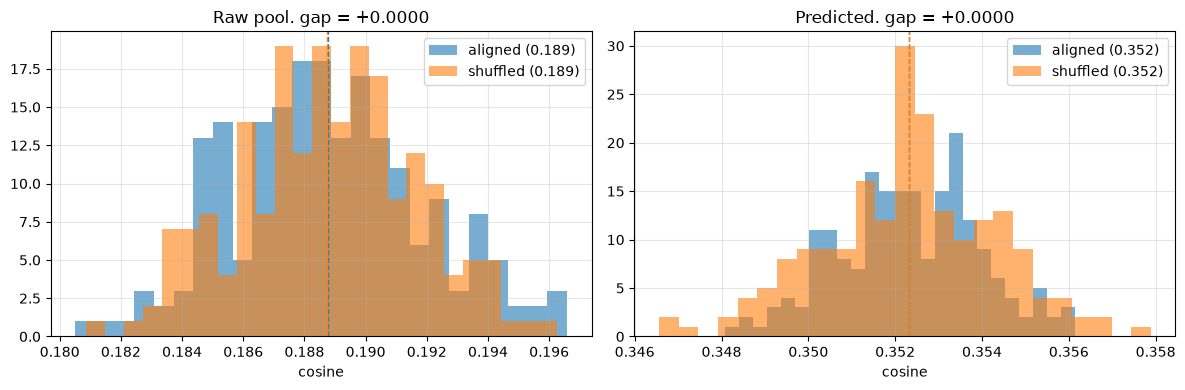

In [ ]:
# Predicted-cosine audit. Self-contained: reloads model + predictor from disk
# if the kernel was restarted. Change AUDIT_MODE below to audit "none" / "aligned" / "shuffled".

AUDIT_MODE = "aligned"
AUDIT_N_PAIRS = 200
AUDIT_SEED = 42

import json, os, re, time
from pathlib import Path
import torch
import torch.nn as nn
from transformers import AutoModelForCausalLM, AutoTokenizer

# Anchor paths if run before setup cells
try:
    _ = NOTEBOOK_DIR
except NameError:
    HERE = Path.cwd()
    REPO = HERE
    while not (REPO / "pyproject.toml").exists() and REPO != REPO.parent:
        REPO = REPO.parent
    NOTEBOOK_DIR = REPO / "notebooks"
    os.chdir(NOTEBOOK_DIR)
    OUTPUT_DIR = NOTEBOOK_DIR / "03-outputs"
    DATA_PATH = NOTEBOOK_DIR / "data" / "nl_sql.jsonl"

_AUDIT_DIR = OUTPUT_DIR / f"model_{AUDIT_MODE}"
if not _AUDIT_DIR.exists():
    raise FileNotFoundError(f"No trained checkpoint at {_AUDIT_DIR}. Run JEPA_MODE={AUDIT_MODE!r} first.")

# System prompt + view helpers (redefine if kernel is fresh)
try:
    _ = SYSTEM_PROMPT
except NameError:
    SYSTEM_PROMPT = (
        "Translate the user's request into a single PostgreSQL statement. "
        "Reply with SQL only, ending in ';'."
    )
    def _chat_msgs(prompt, target=None):
        m = [{"role":"system","content":SYSTEM_PROMPT},{"role":"user","content":prompt}]
        if target is not None: m.append({"role":"assistant","content":target})
        return m
    def build_prompt_text(tokenizer, prompt):
        return tokenizer.apply_chat_template(_chat_msgs(prompt), tokenize=False, add_generation_prompt=True)
    def build_target_text(tokenizer, target):
        return tokenizer.apply_chat_template(
            [{"role":"assistant","content":target}], tokenize=False, add_generation_prompt=False
        )

def _pool_last(hs, am):
    lens = am.sum(dim=1) - 1
    idx = torch.arange(hs.shape[0], device=hs.device)
    return hs[idx, lens]
def _pool_mean(hs, am):
    mask = am.unsqueeze(-1).float()
    return (hs * mask).sum(1) / mask.sum(1).clamp_min(1.0)
def _pool_first(hs, am):
    return hs[:, 0, :]
_POOL = {"last_token": _pool_last, "mean": _pool_mean, "first_token": _pool_first}

def _load_pairs(path):
    return [json.loads(l) for l in Path(path).read_text(encoding="utf-8").splitlines() if l.strip()]
try:
    _ = pairs
except NameError:
    pairs = _load_pairs(DATA_PATH)

# Load or reuse model + tokenizer
try:
    _mdev = next(model.parameters()).device
    _mdt = next(model.parameters()).dtype
    _tok = tokenizer
    _model = model
    print(f"Using in-memory model on {_mdev}, dtype {_mdt}")
except NameError:
    print(f"Loading model from {_AUDIT_DIR}")
    dev = "cuda" if torch.cuda.is_available() else "cpu"
    dt = torch.bfloat16 if (dev == "cuda" and torch.cuda.is_bf16_supported()) else torch.float32
    _tok = AutoTokenizer.from_pretrained(str(_AUDIT_DIR))
    if _tok.pad_token_id is None:
        _tok.pad_token = _tok.eos_token
    _model = AutoModelForCausalLM.from_pretrained(str(_AUDIT_DIR), dtype=dt).to(dev)
    _model.eval()
    _mdev, _mdt = dev, dt

# Predictor: define class if missing, load state
class _Predictor(nn.Module):
    def __init__(self, hidden_dim, depth=2, dropout=0.0):
        super().__init__()
        layers = []
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.GELU()]
            if dropout > 0: layers.append(nn.Dropout(dropout))
        layers.append(nn.Linear(hidden_dim, hidden_dim))
        self.mlp = nn.Sequential(*layers)
    def forward(self, x): return self.mlp(x)

try:
    _pred = predictor
except NameError:
    _pred_sd = torch.load(_AUDIT_DIR / "predictor.pt", map_location="cpu")
    _hd = _model.config.hidden_size
    _n_linear = sum(1 for k in _pred_sd.keys() if k.endswith(".weight"))
    _pred = _Predictor(hidden_dim=_hd, depth=_n_linear)
    _pred.load_state_dict(_pred_sd)
    _pred.eval()

_layer = globals().get("JEPA_LAYER", -1)
_pool = globals().get("JEPA_POOLING", "last_token")
_seq_len = globals().get("SEQ_LEN", 1024)
print(f"pooling={_pool}  layer={_layer}  n_pairs={AUDIT_N_PAIRS}")

@torch.no_grad()
def _encode(texts):
    pf = _POOL[_pool]
    chunks = []
    for i in range(0, len(texts), 4):
        chunk = texts[i:i+4]
        enc = _tok(chunk, return_tensors="pt", padding=True, truncation=True, max_length=_seq_len).to(_mdev)
        out = _model(**enc, output_hidden_states=True)
        z = pf(out.hidden_states[_layer], enc["attention_mask"])
        chunks.append(z.float().cpu())
    return torch.cat(chunks, 0)

audit_pairs = pairs[:AUDIT_N_PAIRS]
prompt_texts = [build_prompt_text(_tok, p["prompt"]) for p in audit_pairs]
target_texts = [build_target_text(_tok, p["target"]) for p in audit_pairs]

print("Encoding prompts...")
z_prompt = _encode(prompt_texts)
print("Encoding targets...")
z_target = _encode(target_texts)
print(f"z_prompt shape: {tuple(z_prompt.shape)}, z_target shape: {tuple(z_target.shape)}")

_pred_cpu = _pred.to("cpu").float().eval()
with torch.no_grad():
    z_pred = _pred_cpu(z_prompt)

def _norm(x): return x / x.norm(dim=-1, keepdim=True).clamp_min(1e-8)
z_prompt_n = _norm(z_prompt)
z_pred_n = _norm(z_pred)
z_target_n = _norm(z_target)

raw_aligned = (z_prompt_n * z_target_n).sum(-1)
pred_aligned = (z_pred_n * z_target_n).sum(-1)
rng = torch.Generator().manual_seed(AUDIT_SEED)
perm = torch.randperm(z_target.shape[0], generator=rng)
raw_shuffled = (z_prompt_n * z_target_n[perm]).sum(-1)
pred_shuffled = (z_pred_n * z_target_n[perm]).sum(-1)

result = {
    "audit_mode": AUDIT_MODE,
    "raw_aligned_mean":  float(raw_aligned.mean()),
    "raw_shuffled_mean": float(raw_shuffled.mean()),
    "raw_gap":           float(raw_aligned.mean() - raw_shuffled.mean()),
    "pred_aligned_mean":  float(pred_aligned.mean()),
    "pred_shuffled_mean": float(pred_shuffled.mean()),
    "pred_gap":           float(pred_aligned.mean() - pred_shuffled.mean()),
}

from IPython.display import Markdown, display
tbl = (
    "| view | aligned | shuffled | **gap** |\n"
    "| --- | --- | --- | --- |\n"
    f"| raw `z_prompt` vs `z_target` | {result['raw_aligned_mean']:.4f} | {result['raw_shuffled_mean']:.4f} | **{result['raw_gap']:+.4f}** |\n"
    f"| **predicted `predictor(z_prompt)` vs `z_target`** | {result['pred_aligned_mean']:.4f} | {result['pred_shuffled_mean']:.4f} | **{result['pred_gap']:+.4f}** |\n"
)
display(Markdown(tbl))

(OUTPUT_DIR / f"repr_audit_predicted_{AUDIT_MODE}.json").write_text(
    json.dumps(result, indent=2), encoding="utf-8"
)
print(f"\nSaved: {OUTPUT_DIR / f'repr_audit_predicted_{AUDIT_MODE}.json'}")

try:
    import matplotlib.pyplot as plt
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.hist(raw_aligned.numpy(), bins=25, alpha=0.6, label=f"aligned ({result['raw_aligned_mean']:.3f})")
    ax1.hist(raw_shuffled.numpy(), bins=25, alpha=0.6, label=f"shuffled ({result['raw_shuffled_mean']:.3f})")
    ax1.axvline(result["raw_aligned_mean"], color="tab:blue", linestyle="--", linewidth=1)
    ax1.axvline(result["raw_shuffled_mean"], color="tab:orange", linestyle="--", linewidth=1)
    ax1.set_title(f"Raw pool. gap = {result['raw_gap']:+.4f}")
    ax1.set_xlabel("cosine"); ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.hist(pred_aligned.numpy(), bins=25, alpha=0.6, label=f"aligned ({result['pred_aligned_mean']:.3f})")
    ax2.hist(pred_shuffled.numpy(), bins=25, alpha=0.6, label=f"shuffled ({result['pred_shuffled_mean']:.3f})")
    ax2.axvline(result["pred_aligned_mean"], color="tab:blue", linestyle="--", linewidth=1)
    ax2.axvline(result["pred_shuffled_mean"], color="tab:orange", linestyle="--", linewidth=1)
    ax2.set_title(f"Predicted. gap = {result['pred_gap']:+.4f}")
    ax2.set_xlabel("cosine"); ax2.legend(); ax2.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
except ImportError:
    pass


## Predictor diversity check (collapse diagnostic)

The predicted-cosine audit above showed `pred_aligned ~ pred_shuffled`. That could mean **predictor collapse**: the predictor outputs essentially the same vector for every prompt, which happens to sit at a moderate cosine to every target.

This cell measures whether that's the case. Three numbers to read:

- `per_dim_std` — the average standard deviation of `z_pred` across the batch, per embedding dim. If it's much lower than `z_target`'s per-dim std (~0.28), the predictor's output is compressed onto a small subspace.
- `mean_pairwise_cos` — average cosine similarity between distinct `z_pred` vectors. If it's near 1.0, every predicted vector is essentially the same.
- `std_of_norms` — dispersion of predicted vector lengths. Constant length = another collapse signature.

**Collapse confirmed if:** `per_dim_std < 0.05` AND `mean_pairwise_cos > 0.95`.


In [ ]:
# Predictor output diversity — collapse diagnostic. Uses variables from the audit cell.
# If those aren't in memory, re-run the audit cell first.

try:
    _ = z_pred
except NameError:
    raise RuntimeError("Run the predicted-cosine audit cell (above) first — z_pred is not in memory.")

n = z_pred.shape[0]

# Per-dim std across the batch of predictions
per_dim_std = float(z_pred.std(dim=0).mean())

# Std of norms
norms = z_pred.norm(dim=-1)
std_of_norms = float(norms.std())
mean_norm = float(norms.mean())

# Mean pairwise cosine (excluding self-similarity)
z_pred_n = z_pred / z_pred.norm(dim=-1, keepdim=True).clamp_min(1e-8)
sim = z_pred_n @ z_pred_n.T
# upper triangle without diagonal
mask = torch.triu(torch.ones_like(sim, dtype=torch.bool), diagonal=1)
mean_pairwise_cos = float(sim[mask].mean())

# Compare to z_target (already normalized to compare like-for-like)
z_target_per_dim_std = float(z_target.std(dim=0).mean())
z_target_mean_norm = float(z_target.norm(dim=-1).mean())

print("Predictor output stats (over 200 samples):")
print(f"  mean_norm            : {mean_norm:.4f}")
print(f"  std_of_norms         : {std_of_norms:.4f}")
print(f"  per_dim_std          : {per_dim_std:.4f}")
print(f"  mean_pairwise_cos    : {mean_pairwise_cos:.4f}")
print()
print("Target (reference for scale):")
print(f"  mean_norm            : {z_target_mean_norm:.4f}")
print(f"  per_dim_std          : {z_target_per_dim_std:.4f}")
print()

# Verdict
collapse = per_dim_std < 0.05 and mean_pairwise_cos > 0.95
partial = per_dim_std < 0.15 and mean_pairwise_cos > 0.80

if collapse:
    verdict = "COLLAPSE CONFIRMED. Predictor is outputting near-constant vectors."
elif partial:
    verdict = "PARTIAL COLLAPSE. Predictor output is compressed but not degenerate."
else:
    verdict = "NO COLLAPSE. Predictor output is diverse. The zero pred_gap is a different problem."

print(f"Verdict: {verdict}")

# Save
diversity = {
    "audit_mode": AUDIT_MODE,
    "z_pred_mean_norm":       mean_norm,
    "z_pred_std_of_norms":    std_of_norms,
    "z_pred_per_dim_std":     per_dim_std,
    "z_pred_mean_pairwise_cos": mean_pairwise_cos,
    "z_target_per_dim_std":   z_target_per_dim_std,
    "z_target_mean_norm":     z_target_mean_norm,
    "verdict":                verdict,
}
(OUTPUT_DIR / f"predictor_diversity_{AUDIT_MODE}.json").write_text(
    __import__("json").dumps(diversity, indent=2), encoding="utf-8"
)
print(f"\nSaved: {OUTPUT_DIR / f'predictor_diversity_{AUDIT_MODE}.json'}")


Predictor output stats (over 200 samples):
  mean_norm            : 43.6194
  std_of_norms         : 0.2220
  per_dim_std          : 0.0813
  mean_pairwise_cos    : 0.9967

Target (reference for scale):
  mean_norm            : 219.5988
  per_dim_std          : 0.2646

Verdict: PARTIAL COLLAPSE. Predictor output is compressed but not degenerate.

Saved: c:\Users\adria\OneDrive\Desktop\mini-llm-jepa\notebooks\03-outputs\predictor_diversity_aligned.json
